In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.models import SmallCNN, DeeperCNN
from src.initialization import initialize_model, initialize_model_mask_first
from src.sparsity_masks import initialize_masks, apply_masks
from src.data import get_mnist_loaders


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [3]:
train_loader, test_loader = get_mnist_loaders(batch_size=64)

In [4]:
# Hyperparameters
batch_size = 64
learning_rate = 0.01
num_epochs = 5

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
criterion = nn.CrossEntropyLoss()

In [7]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            out = model(x)
            preds = torch.argmax(out, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

## sparse + student's t (df = 10)

## 90% sparsity

In [8]:
sparse_model_90_df10 = SmallCNN()
# sparse_model_90_df10 = DeeperCNN()

In [9]:
sparsity = 0.90

In [12]:
initialize_model(sparse_model_90_df10, mode="student", df=10, variance_matched=True, sparsity=sparsity)

In [13]:
masks = initialize_masks(sparse_model_90_df10, sparsity)

In [14]:
with torch.no_grad():
    for name, param in sparse_model_90_df10.named_parameters():
        if name in masks:
            param.mul_(masks[name])

In [15]:
# Loss and optimizer
optimizer = optim.Adam(sparse_model_90_df10.parameters(), lr=learning_rate)

In [16]:
for epoch in range(num_epochs):

    running_loss = 0.0
    
    for x, y in train_loader:

        optimizer.zero_grad()
        output = sparse_model_90_df10(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_90_df10.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.2084
Epoch [2/5], Loss: 0.0776
Epoch [3/5], Loss: 0.0613
Epoch [4/5], Loss: 0.0556
Epoch [5/5], Loss: 0.0500


In [15]:
# Evaluation
sparse_model_90_df10.eval()
correct = 0
total = 0

wrong_images = []
wrong_labels = []
wrong_preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = sparse_model_90_df10(images)
        _, predicted = torch.max(outputs, 1)

        # incorrect predictions
        incorrect = predicted != labels
        wrong_images.extend(images[incorrect].cpu())
        wrong_labels.extend(labels[incorrect].cpu())
        wrong_preds.extend(predicted[incorrect].cpu())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 98.98%


## 99% sparsity

In [8]:
sparse_model_99_df10 = SmallCNN()
# sparse_model_99_df10 = DeeperCNN()

In [9]:
sparsity = 0.99

In [ ]:
initialize_model(sparse_model_99_df10, mode="student", df=10, variance_matched=True, sparsity=sparsity)
# masks = initialize_model_mask_first(sparse_model_99_df10, mode="student", df=10, variance_matched=True, sparsity=sparsity)

In [11]:
masks = initialize_masks(sparse_model_99_df10, sparsity)

In [ ]:
with torch.no_grad():
    for name, param in sparse_model_99_df10.named_parameters():
        if name in masks:
            param.mul_(masks[name])

In [ ]:
# plot weight values

weights = sparse_model_99_df10.fc1.weight.detach().cpu().numpy().flatten()

plt.figure()
plt.hist(np.abs(weights), bins=100, density=True)
plt.yscale("log")
plt.title("Weight Magnitude Distribution (log scale)")
plt.show()

In [11]:
optimizer99 = optim.Adam(sparse_model_99_df10.parameters(), lr=learning_rate)

In [12]:
epoch_grad_vars_99 = []
epoch_grad_means_99 = []
accuracy_history_99 = []

for epoch in range(num_epochs):

    running_loss = 0.0
    grad_norms = []
    
    for x, y in train_loader:

        optimizer99.zero_grad()
        output = sparse_model_99_df10(x)
        loss = criterion(output, y)
        loss.backward()

        total_norm = 0
        for p in sparse_model_99_df10.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        total_norm = total_norm**0.5

        grad_norms.append(total_norm)

        optimizer99.step()
        running_loss += loss.item()

        # Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_99_df10.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
     # per epoch accuracy
    acc = evaluate(sparse_model_99_df10, test_loader)
    print("Epoch accuracy", acc)
    accuracy_history_99.append(acc)

    #per epoch gradient mean and variance
    epoch_grad_means_99.append(np.mean(grad_norms))
    epoch_grad_vars_99.append(np.var(grad_norms))

Epoch [1/5], Loss: 2.2692
Epoch accuracy 0.1619
Epoch [2/5], Loss: 2.2310
Epoch accuracy 0.1586
Epoch [3/5], Loss: 2.2247
Epoch accuracy 0.158
Epoch [4/5], Loss: 2.1919
Epoch accuracy 0.2291
Epoch [5/5], Loss: 2.1562
Epoch accuracy 0.2338


In [13]:
# Evaluation
sparse_model_99_df10.eval()
correct = 0
total = 0

wrong_images = []
wrong_labels = []
wrong_preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = sparse_model_99_df10(images)
        _, predicted = torch.max(outputs, 1)

        # incorrect predictions
        incorrect = predicted != labels
        wrong_images.extend(images[incorrect].cpu())
        wrong_labels.extend(labels[incorrect].cpu())
        wrong_preds.extend(predicted[incorrect].cpu())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 11.35%


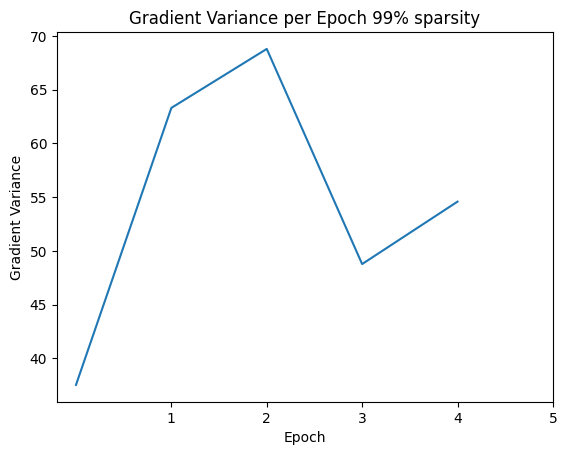

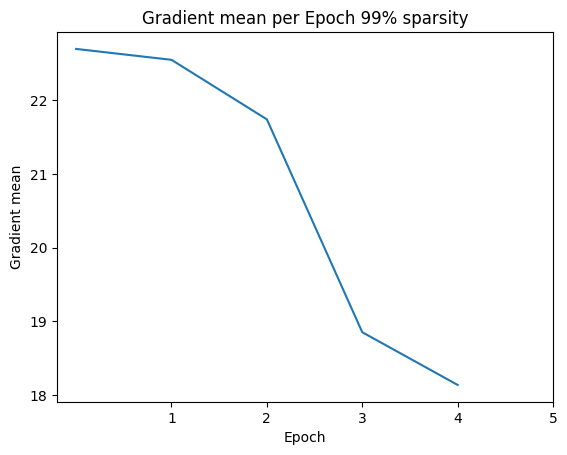

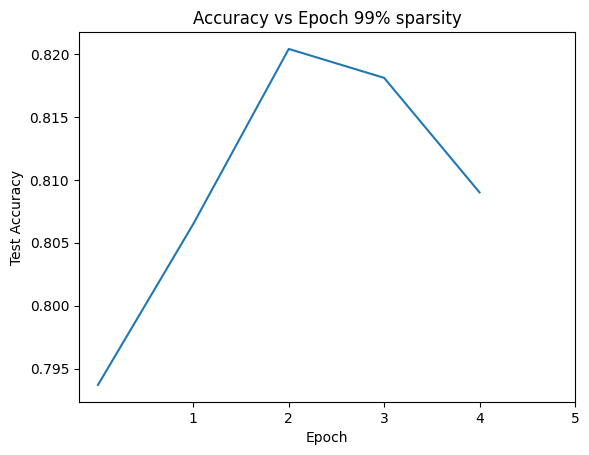

In [14]:
epochs = range(1, len(epoch_grad_vars_99) + 1)
plt.plot(epoch_grad_vars_99)
plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title("Gradient Variance per Epoch 99% sparsity")
plt.xticks(epochs)
plt.show()

# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(epoch_grad_means_99)
plt.xlabel("Epoch")
plt.ylabel("Gradient mean")
plt.title("Gradient mean per Epoch 99% sparsity")
plt.xticks(epochs)
plt.show()

plt.figure()
# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(accuracy_history_99)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epoch 99% sparsity")
plt.xticks(epochs)
plt.show()

## 98% sparsity

In [8]:
# sparse_model_98_df10 = DeeperCNN()
sparse_model_98_df10 = SmallCNN()

In [9]:
sparsity = 0.98

In [ ]:
# masks = initialize_model_mask_first(sparse_model_98_df10, mode="student", df=10, sparsity=sparsity, variance_matched=True)
initialize_model(sparse_model_98_df10, mode="student", df=10, sparsity=sparsity, variance_matched=True)

In [11]:
masks = initialize_masks(sparse_model_98_df10, sparsity)

In [ ]:
with torch.no_grad():
    for name, param in sparse_model_98_df10.named_parameters():
        if name in masks:
            param.mul_(masks[name])

In [11]:
optimizer98 = optim.Adam(sparse_model_98_df10.parameters(), lr=learning_rate)

In [12]:
epoch_grad_vars_98 = []
epoch_grad_means_98 = []
accuracy_history_98 = []

for epoch in range(num_epochs):

    running_loss = 0.0
    grad_norms = []
    
    for x, y in train_loader:

        optimizer98.zero_grad()
        output = sparse_model_98_df10(x)
        loss = criterion(output, y)
        loss.backward()
         ## grad norm per epoch
        total_norm = 0
        for p in sparse_model_98_df10.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        total_norm = total_norm**0.5

        grad_norms.append(total_norm)

        optimizer98.step()
        running_loss += loss.item()

        # Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_98_df10.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
     # per epoch accuracy
    acc = evaluate(sparse_model_98_df10, test_loader)
    print("Epoch accuracy", acc)
    accuracy_history_98.append(acc)

    #per epoch gradient mean and variance
    epoch_grad_means_98.append(np.mean(grad_norms))
    epoch_grad_vars_98.append(np.var(grad_norms))

Epoch [1/5], Loss: 0.8832
Epoch accuracy 0.8099
Epoch [2/5], Loss: 0.6169
Epoch accuracy 0.8084
Epoch [3/5], Loss: 0.5806
Epoch accuracy 0.8279
Epoch [4/5], Loss: 0.5631
Epoch accuracy 0.8247
Epoch [5/5], Loss: 0.5548
Epoch accuracy 0.8356


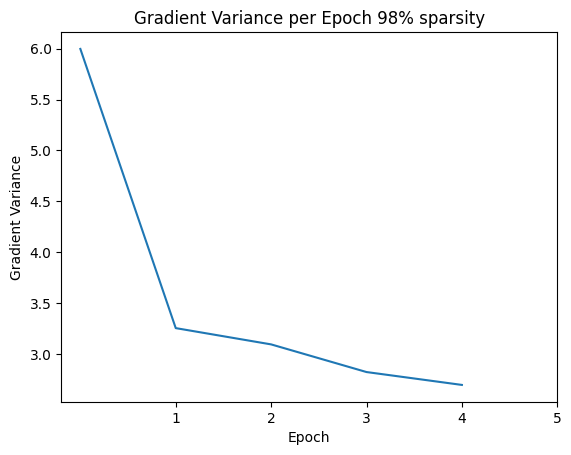

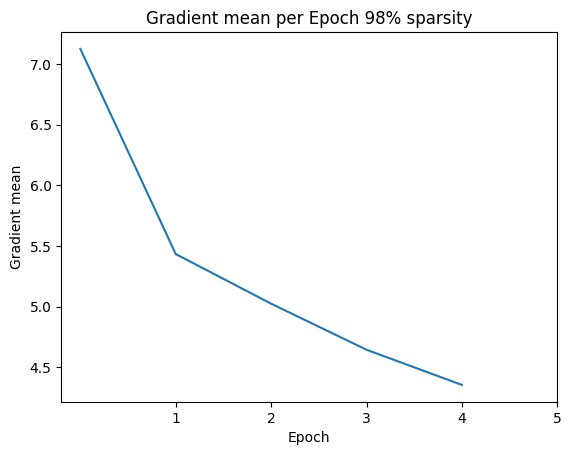

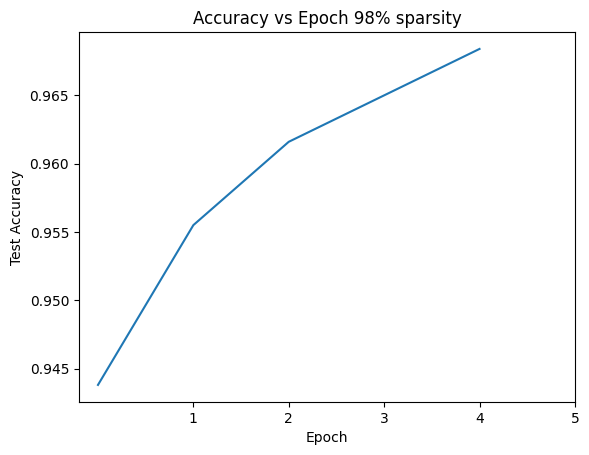

In [26]:
epochs = range(1, len(epoch_grad_vars_98) + 1)
plt.plot(epoch_grad_vars_98)
plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title("Gradient Variance per Epoch 98% sparsity")
plt.xticks(epochs)
plt.show()

# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(epoch_grad_means_98)
plt.xlabel("Epoch")
plt.ylabel("Gradient mean")
plt.title("Gradient mean per Epoch 98% sparsity")
plt.xticks(epochs)
plt.show()

plt.figure()
# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(accuracy_history_98)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epoch 98% sparsity")
plt.xticks(epochs)
plt.show()

## sparse + student's t (df = 2)

## 98% sparsity

In [21]:
# sparse_model_98_df2 = DeeperCNN()
sparse_model_98_df2 = SmallCNN()

In [22]:
sparsity = 0.98


In [23]:
initialize_model(sparse_model_98_df2, mode="student", df=2, variance_matched=True, sparsity=sparsity)

In [24]:
masks = initialize_masks(sparse_model_98_df2, sparsity)

In [25]:
with torch.no_grad():
    for name, param in sparse_model_98_df2.named_parameters():
        if name in masks:
            param.mul_(masks[name])

In [ ]:
# plot weight values

weights = sparse_model_98_df2.fc1.weight.detach().cpu().numpy().flatten()

plt.figure()
plt.hist(np.abs(weights), bins=100, density=True)
plt.yscale("log")
plt.title("Weight Magnitude Distribution (log scale)")
plt.show()

In [26]:
optimizer98_2 = optim.Adam(sparse_model_98_df2.parameters(), lr=learning_rate)

In [19]:
epoch_grad_vars_98_2 = []
epoch_grad_means_98_2 = []
accuracy_history_98_2 = []

for epoch in range(num_epochs):

    running_loss = 0.0
    grad_norms = []
    
    for x, y in train_loader:

        optimizer98_2.zero_grad()
        output = sparse_model_98_df2(x)
        loss = criterion(output, y)
        loss.backward()
         ## grad norm per epoch
        total_norm = 0
        for p in sparse_model_98_df2.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        total_norm = total_norm**0.5

        grad_norms.append(total_norm)

        optimizer98_2.step()
        running_loss += loss.item()

        # Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_98_df2.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
     # per epoch accuracy
    acc = evaluate(sparse_model_98_df2, test_loader)
    print("Epoch accuracy", acc)
    accuracy_history_98_2.append(acc)

    #per epoch gradient mean and variance
    epoch_grad_means_98_2.append(np.mean(grad_norms))
    epoch_grad_vars_98_2.append(np.var(grad_norms))

Epoch [1/5], Loss: 2.3022
Epoch accuracy 0.1028
Epoch [2/5], Loss: 2.3021
Epoch accuracy 0.1135
Epoch [3/5], Loss: 2.3020
Epoch accuracy 0.1135
Epoch [4/5], Loss: 2.3020
Epoch accuracy 0.101
Epoch [5/5], Loss: 2.3021
Epoch accuracy 0.1135


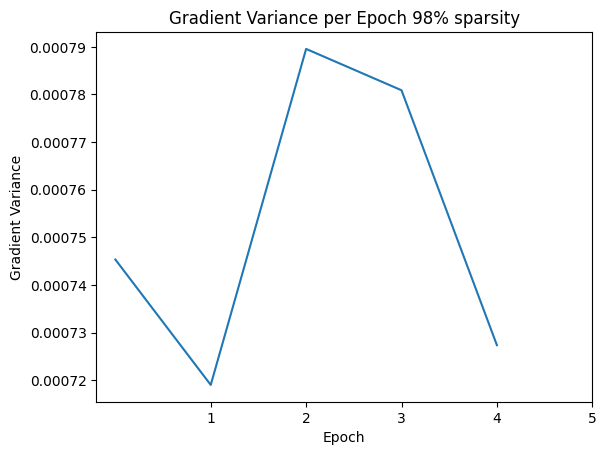

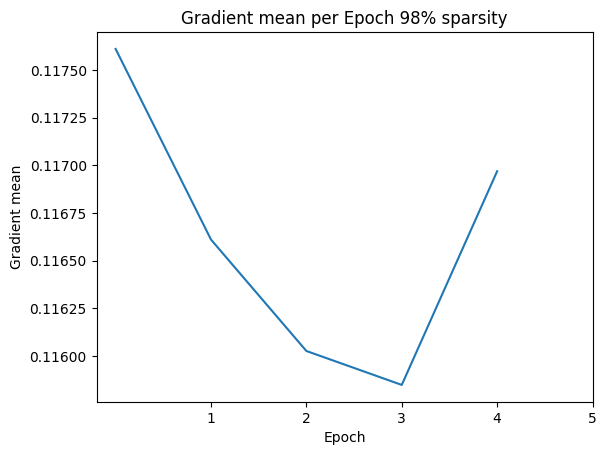

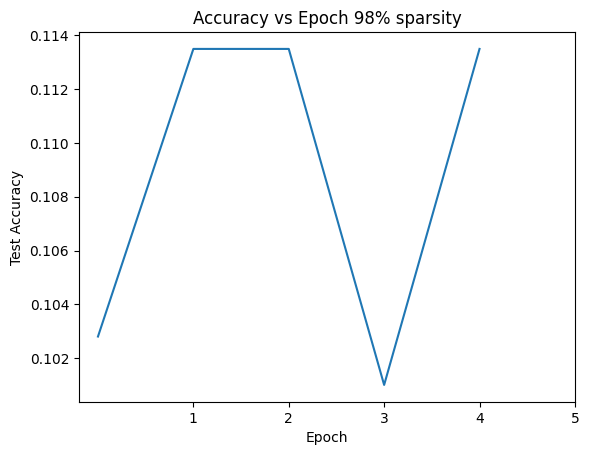

In [20]:
epochs = range(1, len(epoch_grad_vars_98_2) + 1)
plt.plot(epoch_grad_vars_98_2)
plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title("Gradient Variance per Epoch 98% sparsity")
plt.xticks(epochs)
plt.show()

# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(epoch_grad_means_98_2)
plt.xlabel("Epoch")
plt.ylabel("Gradient mean")
plt.title("Gradient mean per Epoch 98% sparsity")
plt.xticks(epochs)
plt.show()

plt.figure()
# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(accuracy_history_98_2)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epoch 98% sparsity")
plt.xticks(epochs)
plt.show()

## 99% sparsity

In [8]:
# sparse_model_99_df2 = DeeperCNN()
sparse_model_99_df2 = SmallCNN()

In [9]:
sparsity = 0.99

In [ ]:
initialize_model(sparse_model_99_df2, mode="student", df=2, variance_matched=True, sparsity=sparsity)
# masks = initialize_model_mask_first(sparse_model_99_df2, mode="student", df=2, variance_matched=True, sparsity=sparsity)

In [ ]:

masks = initialize_masks(sparse_model_99_df2, sparsity)

In [ ]:
with torch.no_grad():
    for name, param in sparse_model_99_df2.named_parameters():
        if name in masks:
            param.mul_(masks[name])

In [11]:
optimizer99_2 = optim.Adam(sparse_model_99_df2.parameters(), lr=learning_rate)

In [ ]:
# plot weight values

weights = sparse_model_99_df2.fc1.weight.detach().cpu().numpy().flatten()

plt.figure()
plt.hist(np.abs(weights), bins=100, density=True)
plt.yscale("log")
plt.title("Weight Magnitude Distribution (log scale)")
plt.show()

In [12]:
epoch_grad_vars_99_2 = []
epoch_grad_means_99_2 = []
accuracy_history_99_2 = []

for epoch in range(num_epochs):

    running_loss = 0.0
    grad_norms = []
    
    for x, y in train_loader:

        optimizer99_2.zero_grad()
        output = sparse_model_99_df2(x)
        loss = criterion(output, y)
        loss.backward()
         ## grad norm per epoch
        total_norm = 0
        for p in sparse_model_99_df2.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        total_norm = total_norm**0.5

        grad_norms.append(total_norm)

        optimizer99_2.step()
        running_loss += loss.item()

        # Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_99_df2.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
     # per epoch accuracy
    acc = evaluate(sparse_model_99_df2, test_loader)
    print("Epoch accuracy", acc)
    accuracy_history_99_2.append(acc)

    #per epoch gradient mean and variance
    epoch_grad_means_99_2.append(np.mean(grad_norms))
    epoch_grad_vars_99_2.append(np.var(grad_norms))

Epoch [1/5], Loss: 1.9070
Epoch accuracy 0.3881
Epoch [2/5], Loss: 1.8112
Epoch accuracy 0.3978
Epoch [3/5], Loss: 1.7983
Epoch accuracy 0.413
Epoch [4/5], Loss: 1.7940
Epoch accuracy 0.3797
Epoch [5/5], Loss: 1.7937
Epoch accuracy 0.3843


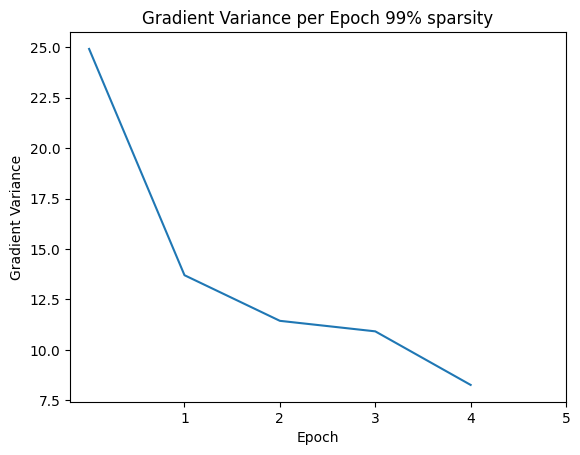

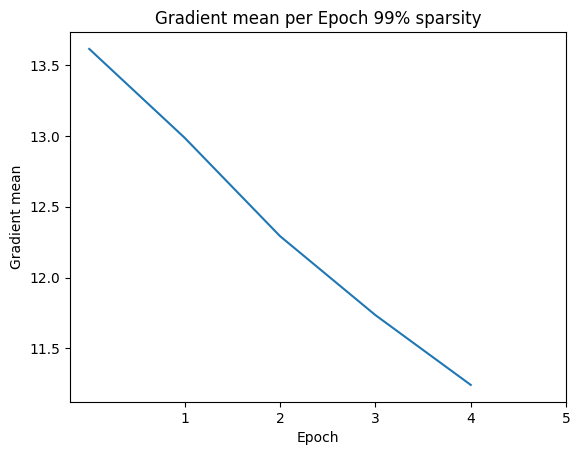

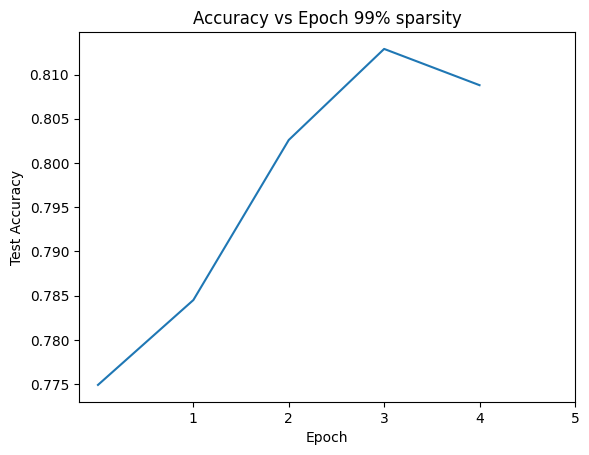

In [ ]:
epochs = range(1, len(epoch_grad_vars_99_2) + 1)
plt.plot(epoch_grad_vars_99_2)
plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title("Gradient Variance per Epoch 99% sparsity")
plt.xticks(epochs)
plt.show()

# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(epoch_grad_means_99_2)
plt.xlabel("Epoch")
plt.ylabel("Gradient mean")
plt.title("Gradient mean per Epoch 99% sparsity")
plt.xticks(epochs)
plt.show()

plt.figure()
# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(accuracy_history_99_2)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epoch 99% sparsity")
plt.xticks(epochs)
plt.show()

In [ ]:
total = 0
zeros = 0

for name, param in sparse_model_99_df2.named_parameters():
    if name in masks:
        total += param.numel()
        zeros += (param == 0).sum().item()

print("Sparsity:", zeros / total)

Sparsity: 0.9901045639179098


## sparse + student's t (df = 5)

## 99% sparsity

In [8]:
# sparse_model_99_df5 = DeeperCNN()
sparse_model_99_df5 = SmallCNN()

In [9]:
sparsity = 0.99

In [ ]:
initialize_model(sparse_model_99_df5, mode="student", df=2, variance_matched=True, sparsity=sparsity)
# masks = initialize_model_mask_first(sparse_model_99_df5, mode="student", df=5, variance_matched=True, sparsity=sparsity)

In [ ]:
masks = initialize_masks(sparse_model_99_df5, sparsity)

In [ ]:
with torch.no_grad():
    for name, param in sparse_model_99_df5.named_parameters():
        if name in masks:
            param.mul_(masks[name])

In [11]:
optimizer99_5 = optim.Adam(sparse_model_99_df5.parameters(), lr=learning_rate)

In [12]:
epoch_grad_vars_99_5 = []
epoch_grad_means_99_5 = []
accuracy_history_99_5 = []

for epoch in range(num_epochs):

    running_loss = 0.0
    grad_norms = []
    
    for x, y in train_loader:

        optimizer99_5.zero_grad()
        output = sparse_model_99_df5(x)
        loss = criterion(output, y)
        loss.backward()
         ## grad norm per epoch
        total_norm = 0
        for p in sparse_model_99_df5.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        total_norm = total_norm**0.5

        grad_norms.append(total_norm)

        optimizer99_5.step()
        running_loss += loss.item()

        # Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_99_df5.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
     # per epoch accuracy
    acc = evaluate(sparse_model_99_df5, test_loader)
    print("Epoch accuracy", acc)
    accuracy_history_99_5.append(acc)

    #per epoch gradient mean and variance
    epoch_grad_means_99_5.append(np.mean(grad_norms))
    epoch_grad_vars_99_5.append(np.var(grad_norms))

Epoch [1/5], Loss: 2.2781
Epoch accuracy 0.1574
Epoch [2/5], Loss: 2.2647
Epoch accuracy 0.1585
Epoch [3/5], Loss: 2.2611
Epoch accuracy 0.1588
Epoch [4/5], Loss: 2.2597
Epoch accuracy 0.1597
Epoch [5/5], Loss: 2.2580
Epoch accuracy 0.1291


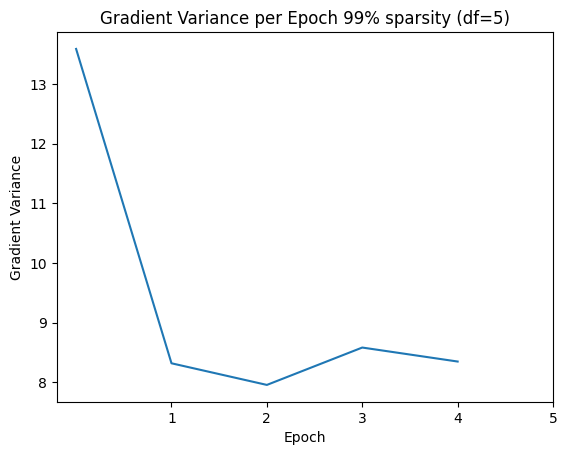

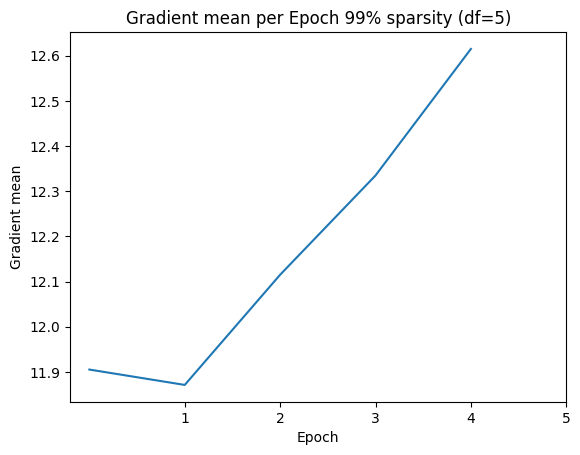

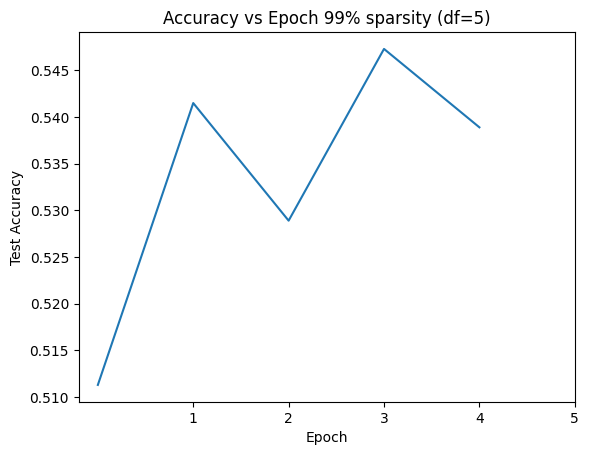

In [ ]:
epochs = range(1, len(epoch_grad_vars_99_5) + 1)
plt.plot(epoch_grad_vars_99_5)
plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title("Gradient Variance per Epoch 99% sparsity (df=5)")
plt.xticks(epochs)
plt.show()

# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(epoch_grad_means_99_5)
plt.xlabel("Epoch")
plt.ylabel("Gradient mean")
plt.title("Gradient mean per Epoch 99% sparsity (df=5)")
plt.xticks(epochs)
plt.show()

plt.figure()
# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(accuracy_history_99_5)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epoch 99% sparsity (df=5)")
plt.xticks(epochs)
plt.show()

## 98% sparsity

In [13]:
# sparse_model_98_df5 = DeeperCNN()
sparse_model_98_df5 = SmallCNN()

In [14]:
sparsity = 0.98

In [ ]:
# masks = initialize_model_mask_first(sparse_model_98_df5, mode="student", df=5, variance_matched=True, sparsity=sparsity)
initialize_model(sparse_model_98_df5, mode="student", df=5, variance_matched=True, sparsity=sparsity)

In [ ]:
masks = initialize_masks(sparse_model_98_df5, sparsity)

In [ ]:
with torch.no_grad():
    for name, param in sparse_model_98_df5.named_parameters():
        if name in masks:
            param.mul_(masks[name])

In [16]:
optimizer98_5 = optim.Adam(sparse_model_98_df5.parameters(), lr=learning_rate)

In [17]:
epoch_grad_vars_98_5 = []
epoch_grad_means_98_5 = []
accuracy_history_98_5 = []

for epoch in range(num_epochs):

    running_loss = 0.0
    grad_norms = []
    
    for x, y in train_loader:

        optimizer98_5.zero_grad()
        output = sparse_model_98_df5(x)
        loss = criterion(output, y)
        loss.backward()
         ## grad norm per epoch
        total_norm = 0
        for p in sparse_model_98_df5.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        total_norm = total_norm**0.5

        grad_norms.append(total_norm)

        optimizer98_5.step()
        running_loss += loss.item()

        # Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_98_df5.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
     # per epoch accuracy
    acc = evaluate(sparse_model_98_df5, test_loader)
    print("Epoch accuracy", acc)
    accuracy_history_98_5.append(acc)

    #per epoch gradient mean and variance
    epoch_grad_means_98_5.append(np.mean(grad_norms))
    epoch_grad_vars_98_5.append(np.var(grad_norms))

Epoch [1/5], Loss: 1.1080
Epoch accuracy 0.707
Epoch [2/5], Loss: 0.9122
Epoch accuracy 0.7209
Epoch [3/5], Loss: 0.8719
Epoch accuracy 0.726
Epoch [4/5], Loss: 0.8584
Epoch accuracy 0.7329
Epoch [5/5], Loss: 0.8522
Epoch accuracy 0.7299
